# Pembuktian Ilmiah: Keunggulan FastText dalam Menangani *Typo* (OOV)

Dokumen ini dirancang secara khusus untuk menjawab pertanyaan penguji skripsi terkait: **"Mengapa memilih arsitektur FastText yang memakan memori bergiga-giga dibandingkan algoritma klasik seperti TF-IDF?"**

Keunggulan absolut FastText terletak pada penanganan **Subword N-grams**. FastText tidak menghafal kata secara utuh, melainkan memecah kata menjadi suku kata kecil (misal: `lap`, `apt`, `pto`, `top`). Sehingga, ketika pelanggan mengetik kata yang salah eja (*typo*) seperti `leptop` yang tidak ada di dalam kamus (*Out-of-Vocabulary* / OOV), FastText tetap bisa merekonstruksi maknanya dan menyadari bahwa kata tersebut memiliki kedekatan matematis dengan kata aslinya.

Sebaliknya, **TF-IDF akan buta total (skor 0.0)** terhadap kata *typo* tersebut jika kata itu belum pernah ia lihat pada saat pelatihan.

In [12]:
import fasttext
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Standarisasi Visualisasi Akademik
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [13]:
print("=== MEMUAT MODEL FASTTEXT 300 DIMENSI ===")
print("Proses ini mungkin membutuhkan waktu karena ukuran model yang besar...")
model_path = 'models/cc.id.300.bin'
try:
    ft_model = fasttext.load_model(model_path)
    print("✅ Model berhasil dimuat ke dalam memori.")
except Exception as e:
    print(f"❌ Gagal memuat model: {e}")

=== MEMUAT MODEL FASTTEXT 300 DIMENSI ===
Proses ini mungkin membutuhkan waktu karena ukuran model yang besar...
✅ Model berhasil dimuat ke dalam memori.


## Pembuktian Rahasia Dapur: Cara Kerja *Subword N-Grams*
Mari kita bedah anatomi mesin FastText. Mengapa ia bisa tahu kata 'leptop' dan 'laptop' itu mirip? Rahasianya ada pada kemampuannya memecah kata menjadi potongan karakter (*Character N-Grams*). Di bawah ini kita akan mengekstrak potongan N-Grams tersebut langsung dari otak model.

In [14]:
print("=== PEMBUKTIAN ANATOMI SUBWORD N-GRAMS ===")
word_baku = 'laptop'
word_typo = 'leptop'

# Mengekstrak n-grams (subwords) yang direkam oleh model FastText
subwords_baku, _ = ft_model.get_subwords(word_baku)
subwords_typo, _ = ft_model.get_subwords(word_typo)

print(f"Subword N-Grams untuk kata baku '{word_baku}':")
print(subwords_baku)
print(f"\nSubword N-Grams untuk kata typo '{word_typo}':")
print(subwords_typo)

# Mencari irisan (potongan suku kata yang kembar)
shared_ngrams = set(subwords_baku).intersection(set(subwords_typo))
print(f"\nPotongan Kembar (Inilah alasan mesin FastText tahu maknanya sama):")
print(list(shared_ngrams))

=== PEMBUKTIAN ANATOMI SUBWORD N-GRAMS ===
Subword N-Grams untuk kata baku 'laptop':
['laptop', '<lapt', 'lapto', 'aptop', 'ptop>']

Subword N-Grams untuk kata typo 'leptop':
['leptop', '<lept', 'lepto', 'eptop', 'ptop>']

Potongan Kembar (Inilah alasan mesin FastText tahu maknanya sama):
['ptop>']


## Pengujian Skala Penuh (*Cosine Similarity*)
Setelah melihat anatomi di atas, mari kita uji secara masif pada variasi kata *typo* yang lebih parah.

In [20]:
print("=== DEFINISI SKENARIO PENGUJIAN TYPO ===")
# Kita buat kamus kata baku vs kata yang sering typo di chat pelanggan
typo_scenarios = {
    'setuju': ['setuju','stuju', 's7', 'setju', 'setujuuu'],
    'batal': ['batl', 'btl', 'baatal', 'batalll'],
    'laptop': ['leptop', 'lepi', 'lepptop', 'lptop'],
    'harga': ['hrga', 'arge', 'harge', 'hargaaa']
}

results = []

for base_word, typos in typo_scenarios.items():
    base_vector = ft_model.get_word_vector(base_word).reshape(1, -1)
    
    # Latih TF-IDF murni hanya pada kata baku (sebagai korpus vocabulary)
    tfidf = TfidfVectorizer()
    tfidf.fit([base_word])
    base_tfidf = tfidf.transform([base_word])
    
    for typo in typos:
        typo_vector = ft_model.get_word_vector(typo).reshape(1, -1)
        # Menghitung kemiripan sudut (Cosine Similarity) FastText
        sim_ft = cosine_similarity(base_vector, typo_vector)[0][0]
        
        # Menghitung kemiripan TF-IDF (OOV test)
        typo_tfidf = tfidf.transform([typo])
        sim_tfidf = cosine_similarity(base_tfidf, typo_tfidf)[0][0]
        
        results.append({
            'Kata Baku': base_word,
            'Kata Typo / Gaul': typo,
            'Skor Kedekatan FastText': sim_ft,
            'Skor TF-IDF': sim_tfidf
        })

df_results = pd.DataFrame(results)
display(df_results)

=== DEFINISI SKENARIO PENGUJIAN TYPO ===


,Kata Baku,Kata Typo / Gaul,Skor Kedekatan FastText,Skor TF-IDF
0,setuju,setuju,1.000000,1.0
1,setuju,stuju,0.574221,0.0
2,setuju,s7,-0.031315,0.0
3,setuju,setju,0.136144,0.0
4,setuju,setujuuu,0.652813,0.0
5,batal,batl,0.173752,0.0
6,batal,btl,0.085438,0.0
7,batal,baatal,0.496052,0.0
8,batal,batalll,0.626893,0.0
9,laptop,leptop,0.768930,0.0


=== VISUALISASI 1: HEATMAP COSINE SIMILARITY ===


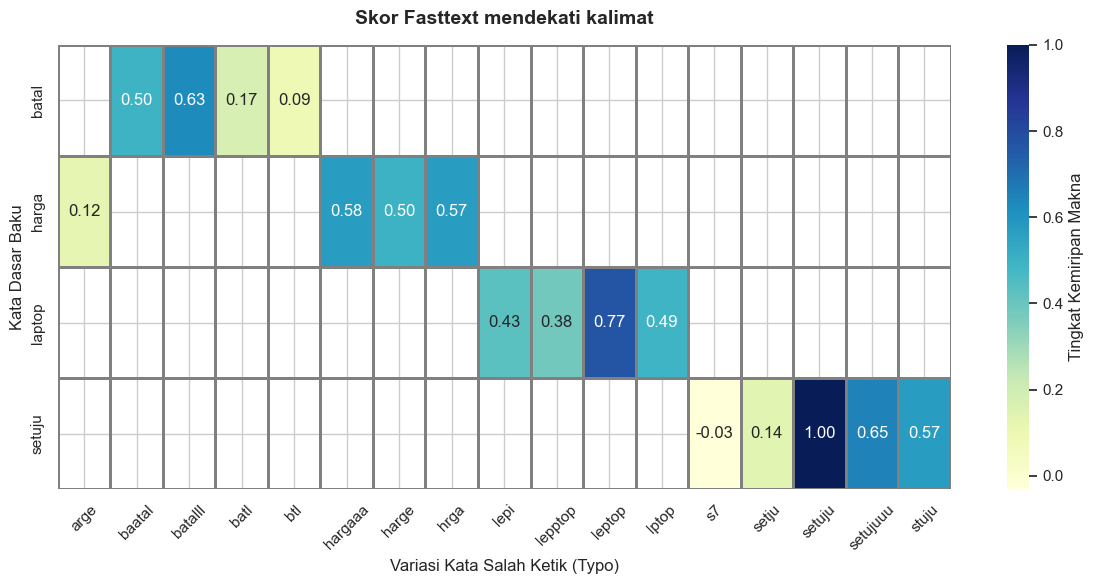

In [25]:
print("=== VISUALISASI 1: HEATMAP COSINE SIMILARITY ===")
# Membuat matriks pivot untuk Heatmap
heatmap_data = df_results.pivot(index='Kata Baku', columns='Kata Typo / Gaul', values='Skor Kedekatan FastText')

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", linewidths=1, linecolor='gray', fmt=".2f", cbar_kws={'label': 'Tingkat Kemiripan Makna'})
plt.title('Skor Fasttext mendekati kalimat', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Variasi Kata Salah Ketik (Typo)', fontsize=12)
plt.ylabel('Kata Dasar Baku', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== JEJAK TYPO DI RUANG VEKTOR (PCA) ===


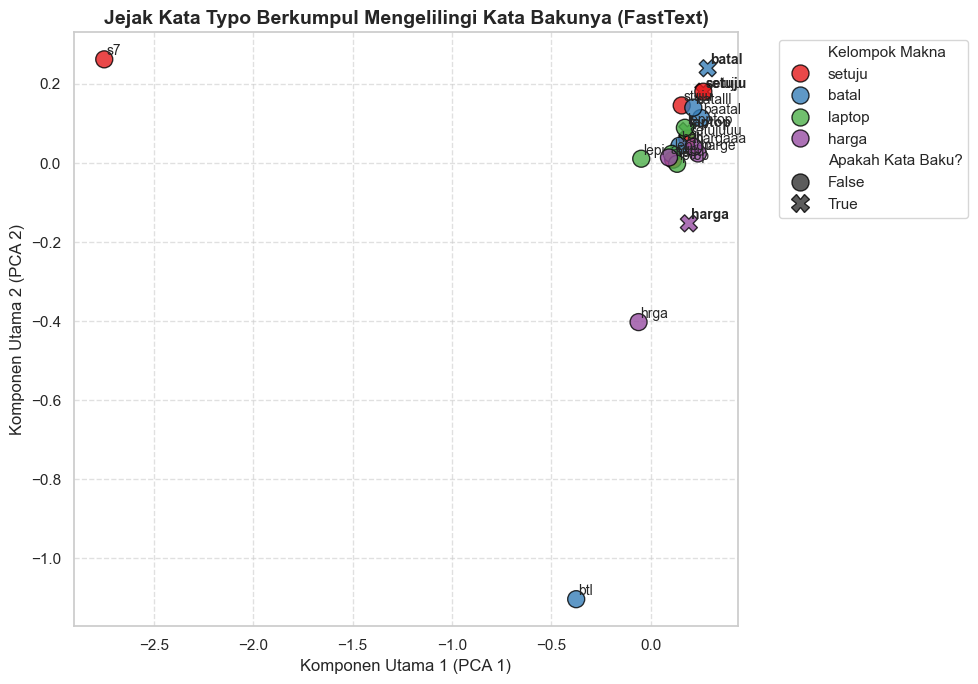


KESIMPULAN:
Visualisasi ini membuktikan bahwa kata-kata salah ketik (typo) tidak dibuang oleh FastText.
Mereka membentuk jejak rasi bintang yang berkumpul rapat mengelilingi kata dasarnya.


In [23]:
print("=== JEJAK TYPO DI RUANG VEKTOR (PCA) ===")
all_words = []
labels = []
is_base = []

# Kumpulkan semua kata
for base_word, typos in typo_scenarios.items():
    all_words.append(base_word)
    labels.append(base_word)
    is_base.append(True)
    
    for typo in typos:
        all_words.append(typo)
        labels.append(base_word) # Tetap labeli dengan kata dasarnya untuk warna
        is_base.append(False)

# Ekstrak vektor untuk semua kata
X = np.array([ft_model.get_word_vector(w) for w in all_words])

# Reduksi ke 2 Dimensi menggunakan PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame({
    'Kata': all_words,
    'Kelompok Makna': labels,
    'Apakah Kata Baku?': is_base,
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1]
})

plt.figure(figsize=(10, 7))

# Plot Titik (Membesarkan ukuran titik untuk kata baku)
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Kelompok Makna', style='Apakah Kata Baku?', 
                palette='Set1', s=150, edgecolor='black', alpha=0.8, markers={True: 'X', False: 'o'})

# Beri label teks di setiap titik
for i in range(len(df_pca)):
    plt.text(df_pca['PCA1'].iloc[i] + 0.01, df_pca['PCA2'].iloc[i] + 0.01, 
             df_pca['Kata'].iloc[i], fontsize=10, fontweight='bold' if df_pca['Apakah Kata Baku?'].iloc[i] else 'normal')

plt.title('Jejak Kata Typo Berkumpul Mengelilingi Kata Bakunya (FastText)', fontsize=14, fontweight='bold')
plt.xlabel('Komponen Utama 1 (PCA 1)')
plt.ylabel('Komponen Utama 2 (PCA 2)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nKESIMPULAN:")
print("Visualisasi ini membuktikan bahwa kata-kata salah ketik (typo) tidak dibuang oleh FastText.")
print("Mereka membentuk jejak rasi bintang yang berkumpul rapat mengelilingi kata dasarnya.")


## Perbandingan Visual Mutlak: FastText vs TF-IDF
Grafik batang di bawah ini membandingkan secara *head-to-head* (langsung) bagaimana mesin FastText dan mesin TF-IDF memberikan skor kepada kata-kata yang ejaannya salah (OOV). TF-IDF benar-benar lumpuh jika kata tidak persis identik.

=== VISUALISASI 3: BAR CHART KOMPARASI FASTTEXT VS TF-IDF ===


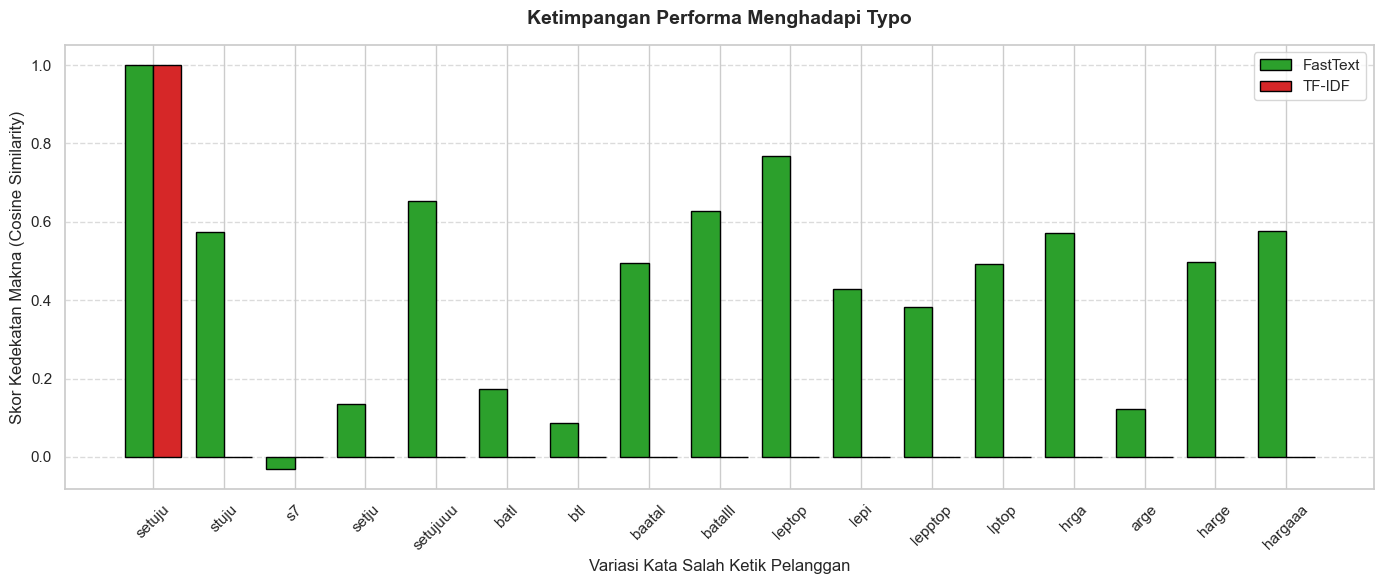

In [24]:
print("=== VISUALISASI 3: BAR CHART KOMPARASI FASTTEXT VS TF-IDF ===")
plt.figure(figsize=(14, 6))

x = np.arange(len(df_results['Kata Typo / Gaul']))
width = 0.4

plt.bar(x - width/2, df_results['Skor Kedekatan FastText'], width, label='FastText', color='#2ca02c', edgecolor='black')
plt.bar(x + width/2, df_results['Skor TF-IDF'], width, label='TF-IDF', color='#d62728', edgecolor='black')

plt.title('Ketimpangan Performa Menghadapi Typo', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Variasi Kata Salah Ketik Pelanggan', fontsize=12)
plt.ylabel('Skor Kedekatan Makna (Cosine Similarity)', fontsize=12)
plt.xticks(x, df_results['Kata Typo / Gaul'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
